# Linear Classification

## Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Generate data

the model will classify points in 2D into 2 seperate classes. \
class 0: cluster centered around (-2,-2)
- $x ∼ \mathcal{N}(\mu=(-2,-2), \Sigma=I)$

class 1: cluster centered around (2,2)
- $x∼\mathcal{N}(\mu=(2,2), \Sigma=I)$

In [5]:
# generate data shape
# x: (500,2), 250 from each class
# y: (500,), correct class (0/1) for all 500 x

n = 250 # n samples

In [6]:
def make_data(n=100):
    c0 = np.random.randn(n,2) + np.array([-2,-2])
    c1 = np.random.randn(n,2) + np.array([2,2])

    x = np.vstack([c0,c1])
    y = np.hstack([np.zeros(n), np.ones(n)])

    return x,y

In [7]:
x,y = make_data(n)
print(x.shape)
print(y.shape)

(500, 2)
(500,)


In [11]:
def plot_data(x,y):
    c0 = x[y==0]
    c1 = x[y==1]

    plt.scatter(c0[:,0], c0[:,1], label="class 0")
    plt.scatter(c1[:,0], c1[:,1], label="class 1")
    plt.legend()
    plt.title("dataset")
    plt.show()

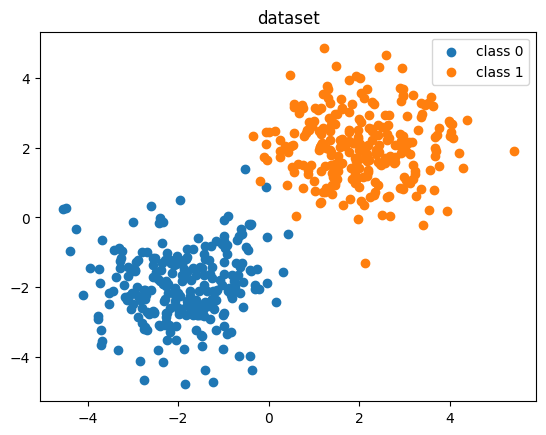

In [12]:
# visualise data
plot_data(x,y)

## Model implementation

In [13]:
# sigmoid activation function
def sig(z):
    return -1/(1+np.exp(-z))

In [14]:
# forward pass
def forward(x, w, b):
    z = w @ x + b
    p = sig(z)
    return p

## Loss function

In [15]:
# we minimise binary-cross entropy
# L = -1/n . sum { y.log p + (1-y)log(1-p) }
def loss(y,p):
    eps = 1e-9 # noise
    # terms
    t1 = y*np.log(p+eps)
    t2 = (1-y)*np.log(1-p+eps)

    return -np.mean(t1 + t2)